# Live Coding: Regression Evaluation Metrics
**Course**: AI Engineering - Machine Learning  
**Project**: House Price Prediction  
**Notebook**: `Live_Coding_Regression_Evaluation.ipynb`

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

if os.path.exists("data/processed/X_test.csv"):
    data_dir = "data/processed"
    models_dir = "models"
else:
    data_dir = "../data/processed"
    models_dir = "../models"

X_test_path = os.path.join(data_dir, "X_test.csv")
y_test_path = os.path.join(data_dir, "y_test.csv")
model_path = os.path.join(models_dir, "best_model.pkl")

X_test = pd.read_csv(X_test_path)
y_test_df = pd.read_csv(y_test_path)
y_test = y_test_df.values.ravel()

best_model = joblib.load(model_path)
y_pred = best_model.predict(X_test)

print("Model and Test Data loaded successfully!")
print("Model Type:", best_model.__class__.__name__)
print("Number of test houses:", len(y_test))
print("First 5 real prices:      ", [round(p, 2) for p in y_test[:5]])
print("First 5 predicted prices: ", [round(p, 2) for p in y_pred[:5]])

Model and Test Data loaded successfully!
Model Type: TransformedTargetRegressor
Number of test houses: 292
First 5 real prices:       [184000.0, 181000.0, 145000.0, 115000.0, 84000.0]
First 5 predicted prices:  [167482.15, 152548.82, 131338.31, 128151.76, 83699.69]


## Real vs Predicted Prices

In [ ]:
comparison_df = pd.DataFrame({
    "Real Price": y_test,
    "Predicted Price": y_pred,
})
comparison_df["Real - Predicted"] = comparison_df["Real Price"] - comparison_df["Predicted Price"]
comparison_df.head(10)

## Evaluation Metrics

### MAE

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")

### MSE and RMSE

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error (MSE):       {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

### R² Score

In [ ]:
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f} ({r2*100:.2f}%)")

### Metrics Summary

In [ ]:
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2],
    "Description": [
        "Average absolute difference between real and predicted prices",
        "Like MAE but penalizes large errors more, in the same unit as price",
        "Share of price variance explained by the model (1.0 = perfect)",
    ],
})
metrics_df

## Visualizations

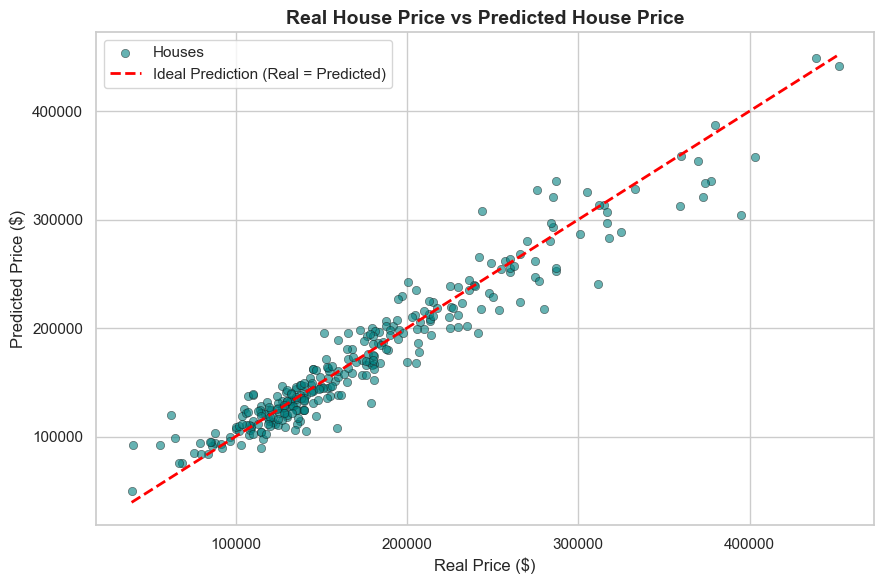

In [3]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal', edgecolor='k', label='Houses')
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (Real = Predicted)')
plt.title("Real House Price vs Predicted House Price", fontsize=14, fontweight='bold')
plt.xlabel("Real Price ($)", fontsize=12)
plt.ylabel("Predicted Price ($)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()